In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)

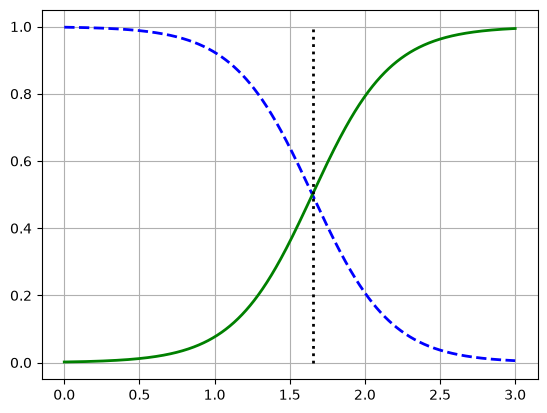

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = iris.data[["petal width (cm)"]].values
y = iris.target_names[iris.target] == 'virginica'

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
y_proba = log_reg.predict_proba(X_new)
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]

plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2,
label="Not Iris virginica proba")
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="Iris virginica proba")
plt.plot([decision_boundary, decision_boundary], [0, 1], "k:", linewidth=2,
label="Decision boundary")

plt.grid()
plt.show()

Softmax Regression

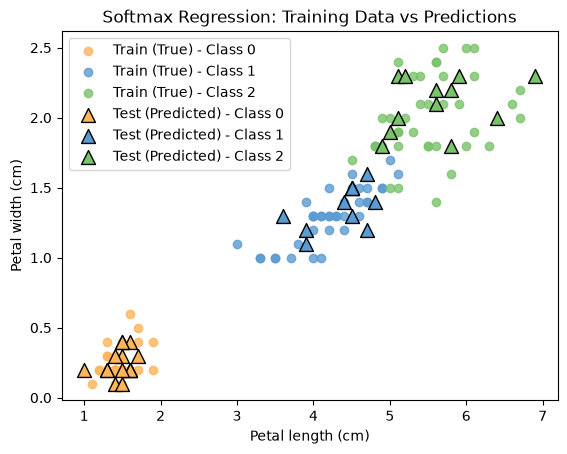

In [18]:
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

softmax_reg = LogisticRegression(C=30, random_state=42)
softmax_reg.fit(X_train, y_train)

y_predict_test = softmax_reg.predict(X_test)

colors = ["#ffb55a", "#5a9bd4", "#7ac36a"]

for class_value in range(3):
    X_class_train = X_train[y_train == class_value]
    plt.scatter(X_class_train[:, 0], X_class_train[:, 1], 
                c=colors[class_value], marker='o', alpha=0.8, 
                label=f"Train (True) - Class {class_value}")

for class_value in range(3):
    X_class_test = X_test[y_predict_test == class_value]
    plt.scatter(X_class_test[:, 0], X_class_test[:, 1], 
                c=colors[class_value], marker='^', s=100, edgecolor='black', 
                label=f"Test (Predicted) - Class {class_value}")

plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Softmax Regression: Training Data vs Predictions")
plt.legend()
plt.show()